In [ ]:
import numpy as np
with open('x_65dims.npy', 'rb') as f:
    X = np.load(f)

In [1]:
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting

corpus = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]} without {X[InIdiom=Yes];X[Idiom=Yes]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="coverage"
)

connected to port: 56202


Number of matches after filtering: 11701


In [3]:
import tod.dimension_reduction_own
X_coverage, X_precision, X_pmi, X_geometric_mean, X_tfidf = corpus.show_variance_graphs()

In [ ]:
dim_red_corr = tod.dimension_reduction_own.HighCorrelation(corpus, threshold=0.9)
dim_red_freq = tod.dimension_reduction_own.Frequency(corpus, dim_red_corr, lower_bound=100, upper_bound=4500)
dim_red_variance = tod.dimension_reduction_own.Variance(corpus, dim_red_corr, X_pmi, threshold=0.25)
dim_red_random = tod.dimension_reduction_own.Random(corpus, dim_red_corr, threshold=0.25)
dim_red_complete = tod.dimension_reduction_own.DimensionReductionComplete(corpus, dim_red_corr, dim_red_freq, dim_red_variance, dim_red_random)
X_final = dim_red_complete.final_matrix

In [ ]:
corpus.feature_matrix.shape

In [ ]:
dim_red_corr.show_result()

In [ ]:
X_final.shape

In [ ]:
dim_red_complete.show_result()

In [ ]:
X = X_final

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from adjustText import adjust_text  # Import the adjustText library

# Perform K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)  # Adjust n_clusters as needed
labels = kmeans.fit_predict(X)

# Perform PCA for 2D projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create the scatter plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)

# Add lexical unit labels to each point with lines
texts = []
for i, adverb in enumerate([corpus.idx2lexunit(i) for i in range(len(X))]):  # Replace with your lexical unit extraction logic
    texts.append(plt.text(X_pca[i, 0], X_pca[i, 1], adverb, fontsize=8, ha='right', va='bottom', alpha=0.7))

# Adjust text positions to avoid overlap and add connecting lines
adjust_text(
    texts,
    X_pca[:, 0],  # X-coordinates of points
    X_pca[:, 1],  # Y-coordinates of points
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)  # Draw lines from points to text
)

# Add plot titles and labels
plt.title("K-Means Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
import plotly.express as px
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Perform K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)  # Adjust n_clusters as needed
labels = kmeans.fit_predict(X)

# Perform PCA for 2D projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for easier handling of data
df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': labels,
    'Lexical Unit': [corpus.idx2lexunit(i)[0] for i in range(len(X))]  # Replace with your lexical unit extraction logic
})

# Create an interactive scatter plot with Plotly
fig = px.scatter(
    df,
    x='PCA1',
    y='PCA2',
    color='Cluster',  # Color by cluster
    hover_data={'Lexical Unit': True, 'PCA1': ':.2f', 'PCA2': ':.2f'},  # Add hover text
    title="K-Means Clustering (PCA Projection)"
)

# Customize layout
fig.update_layout(
    xaxis_title="Principal Component 1",
    yaxis_title="Principal Component 2",
    legend_title="Cluster",
    template="plotly"
)

# Show the interactive plot
fig.show()

In [ ]:
print(pca.explained_variance_ratio_)

In [4]:
import tod.dimension_reduction_classic
import tod.dimension_reduction_own
import tod.corpus

treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master"
grew_pattern="pattern {X[upos=ADV]} without {X[InIdiom=Yes];X[Idiom=Yes]}"
patterns_text_file="../3. probability_matrix/patterns_adv.txt"

types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
dim_reds = {}
matrices = {}
for type_of_matrix in types_of_matrix:
    corpus = tod.corpus.Corpus(
    treebank_path=treebank_path,
    grew_pattern=grew_pattern,
    patterns_text_file=patterns_text_file,
    matrix_type=type_of_matrix
)
    dim_red_corr = tod.dimension_reduction_own.HighCorrelation(corpus, threshold=0.9)
    dim_red_freq = tod.dimension_reduction_own.Frequency(corpus, dim_red_corr, lower_bound=100, upper_bound=4500)
    dim_red_variance = tod.dimension_reduction_own.Variance(corpus, dim_red_corr, X_pmi, threshold=0.25)
    dim_red_random = tod.dimension_reduction_own.Random(corpus, dim_red_corr, threshold=0.25)
    dim_red_complete = tod.dimension_reduction_own.DimensionReductionComplete(corpus, dim_red_corr, dim_red_freq, dim_red_variance, dim_red_random)
    x = dim_red_complete.final_matrix
    matrices[type_of_matrix] = x
    dim_reds[type_of_matrix] = {"pca": tod.dimension_reduction_classic.Pca_matrix(x), "tsne": tod.dimension_reduction_classic.Tsne_matrix(x)}

Number of matches after filtering: 11701
Make sure you have chosen the correct matrix to extract the variance from. You can do that by calling the show_variance_graphs() function in the corpus class.
Number of matches after filtering: 11701
Make sure you have chosen the correct matrix to extract the variance from. You can do that by calling the show_variance_graphs() function in the corpus class.
Number of matches after filtering: 11701
Make sure you have chosen the correct matrix to extract the variance from. You can do that by calling the show_variance_graphs() function in the corpus class.
Number of matches after filtering: 11701
Make sure you have chosen the correct matrix to extract the variance from. You can do that by calling the show_variance_graphs() function in the corpus class.
Number of matches after filtering: 11701
Make sure you have chosen the correct matrix to extract the variance from. You can do that by calling the show_variance_graphs() function in the corpus class.


In [7]:
import numpy as np
for type_of_matrix in types_of_matrix:
    with open(f"{type_of_matrix}_reduced_dims.npy", 'wb') as f:
        np.save(f, matrices[type_of_matrix])

In [6]:
dim_reds

{'precision': {'pca': <tod.dimension_reduction_classic.Pca_matrix at 0x356e577d0>,
  'tsne': <tod.dimension_reduction_classic.Tsne_matrix at 0x3574f2050>},
 'coverage': {'pca': <tod.dimension_reduction_classic.Pca_matrix at 0x3562b8190>,
  'tsne': <tod.dimension_reduction_classic.Tsne_matrix at 0x176bd9490>},
 'PMI': {'pca': <tod.dimension_reduction_classic.Pca_matrix at 0x35723cbd0>,
  'tsne': <tod.dimension_reduction_classic.Tsne_matrix at 0x358780c10>},
 'tf-idf': {'pca': <tod.dimension_reduction_classic.Pca_matrix at 0x357531c50>,
  'tsne': <tod.dimension_reduction_classic.Tsne_matrix at 0x356abcd90>},
 'geometric_mean': {'pca': <tod.dimension_reduction_classic.Pca_matrix at 0x357a3df90>,
  'tsne': <tod.dimension_reduction_classic.Tsne_matrix at 0x3588d3650>}}

In [ ]:
# for type_of_matrix in types_of_matrix:
#     for dim_red, _ in dim_reds[type_of_matrix].items():
#             fig = tod.plotting.lexunit_scatter_plot(corpus, dim_reds[type_of_matrix][dim_red])
#             fig.write_html("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/17.tidy_clustering/" + type_of_matrix + "_" + dim_red + ".html")

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text  # Import the adjustText library
def lexunit_scatter_plot(corpus, dimension_reduction, title):
    # Create a DataFrame for the data
    data = pd.DataFrame(
        {
            "Component 1": dimension_reduction.reduced_matrix[:, 0],
            "Component 2": dimension_reduction.reduced_matrix[:, 1],
            "Lexical Unit": [
                corpus.idx2lexunit(i)
                for i in range(len(dimension_reduction.reduced_matrix))
            ],
        }
    )

    # Create the scatter plot
    plt.figure(figsize=(10, 7))
    plt.scatter(data["Component 1"], data["Component 2"], s=50, alpha=0.7, c='blue')

    # Add text annotations for lexical units
    texts = []
    for i, row in data.iterrows():
        texts.append(plt.text(row["Component 1"], row["Component 2"], row["Lexical Unit"], fontsize=8, alpha=0.7))

    # Adjust text positions to avoid overlap (optional)
    adjust_text(
        texts,
        data["Component 1"],
        data["Component 2"],
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)  # Draw lines from points to text
    )

    # Add plot titles and labels
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

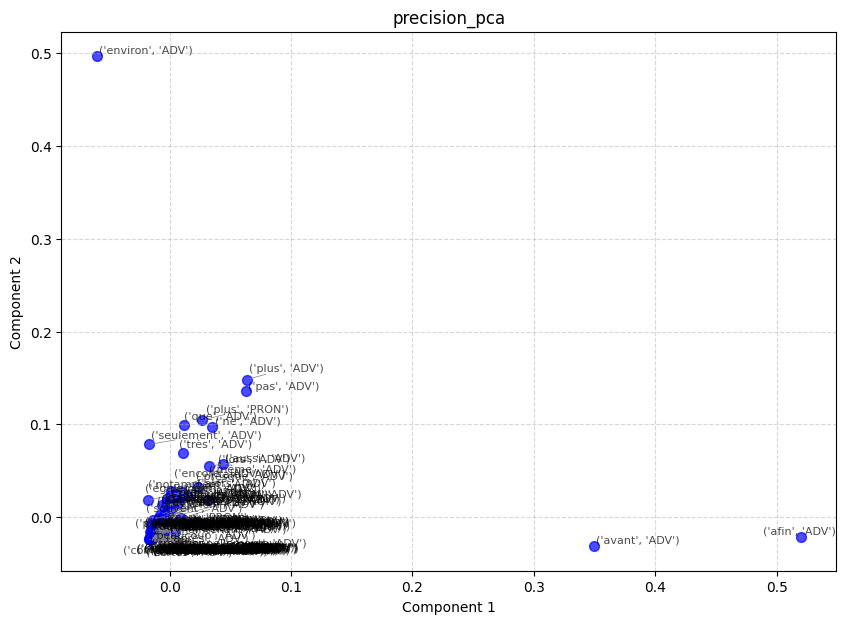

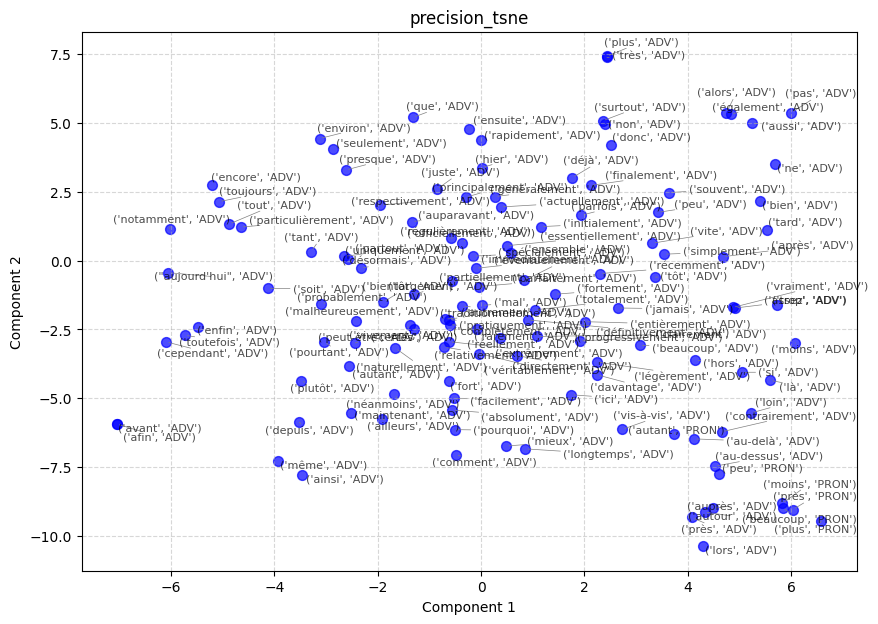

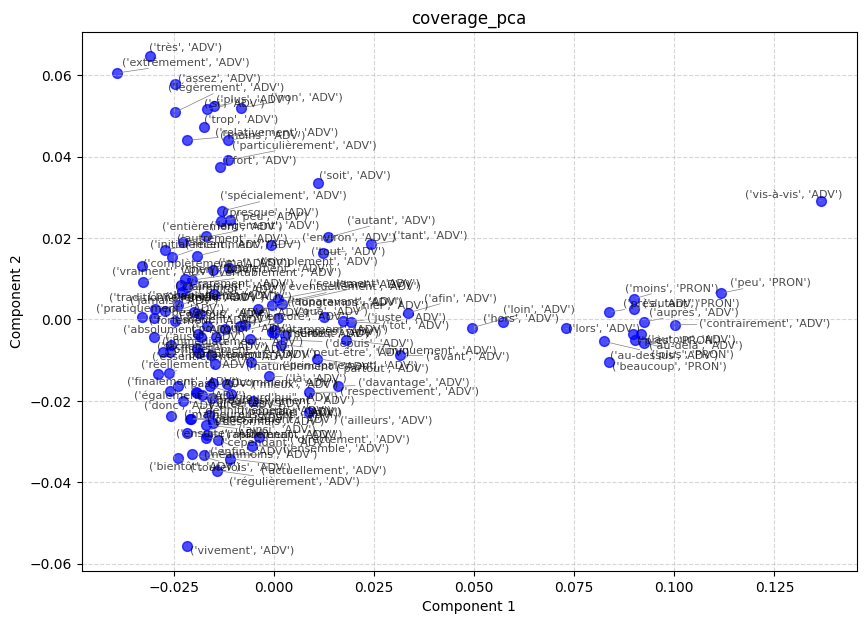

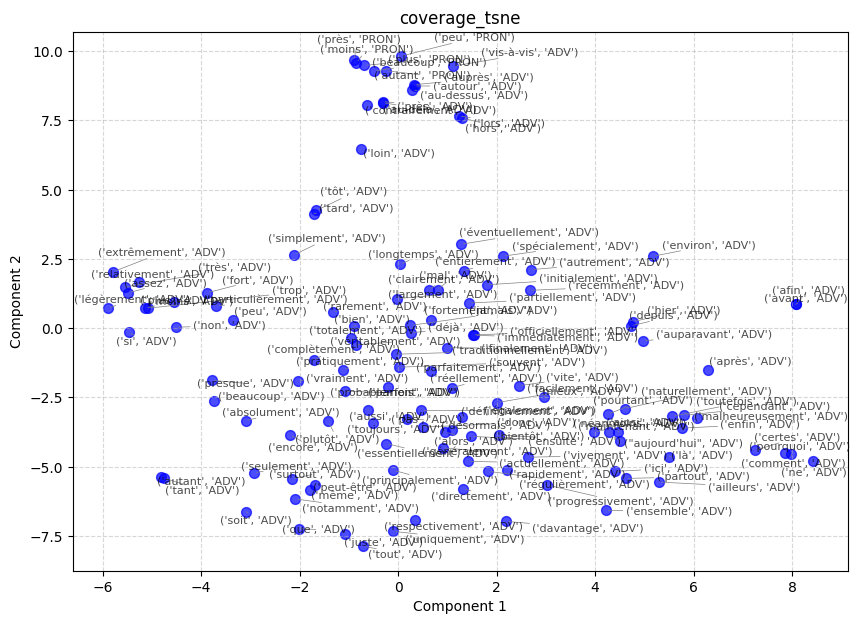

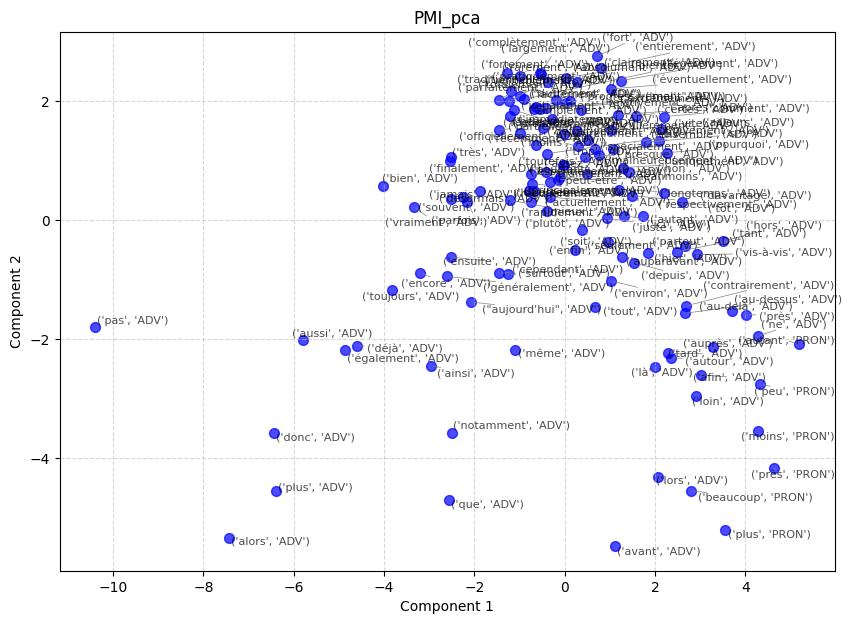

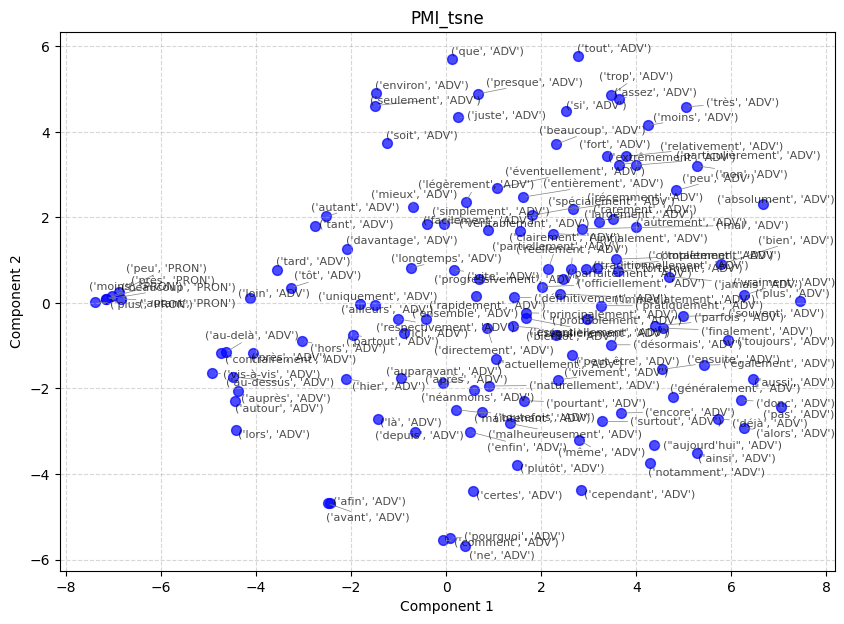

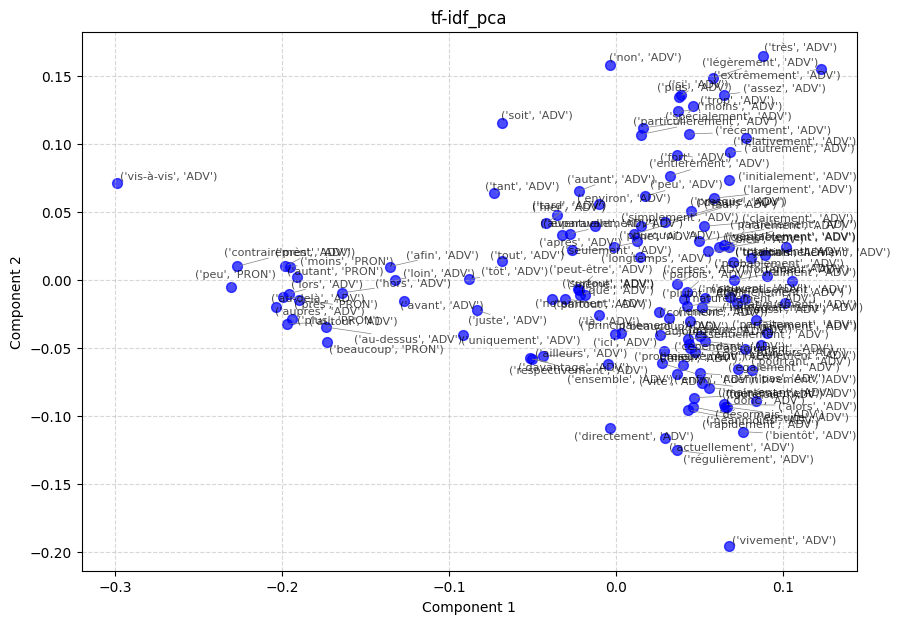

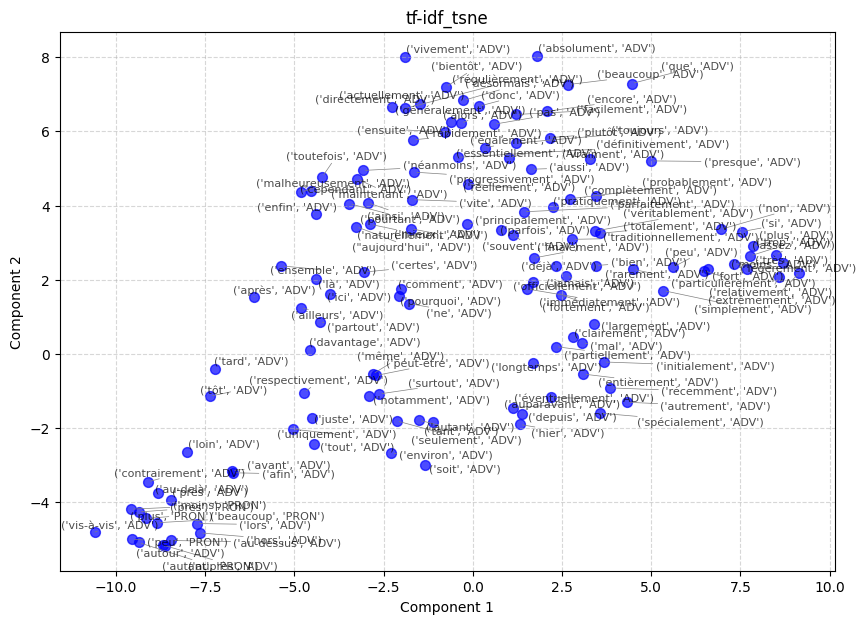

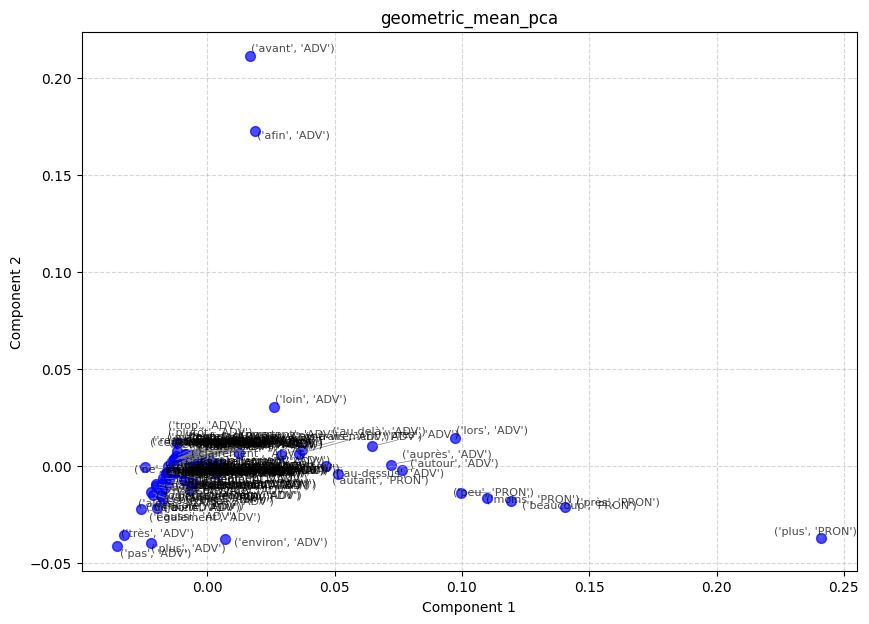

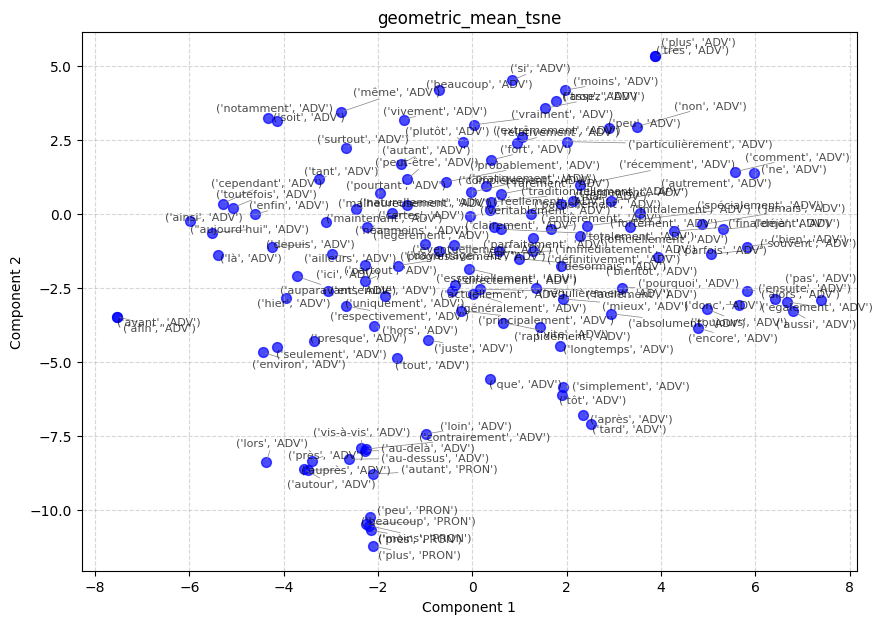

In [12]:
for type_of_matrix in types_of_matrix:
    for dim_red, _ in dim_reds[type_of_matrix].items():
            lexunit_scatter_plot(corpus, dim_reds[type_of_matrix][dim_red], type_of_matrix + "_" + dim_red)

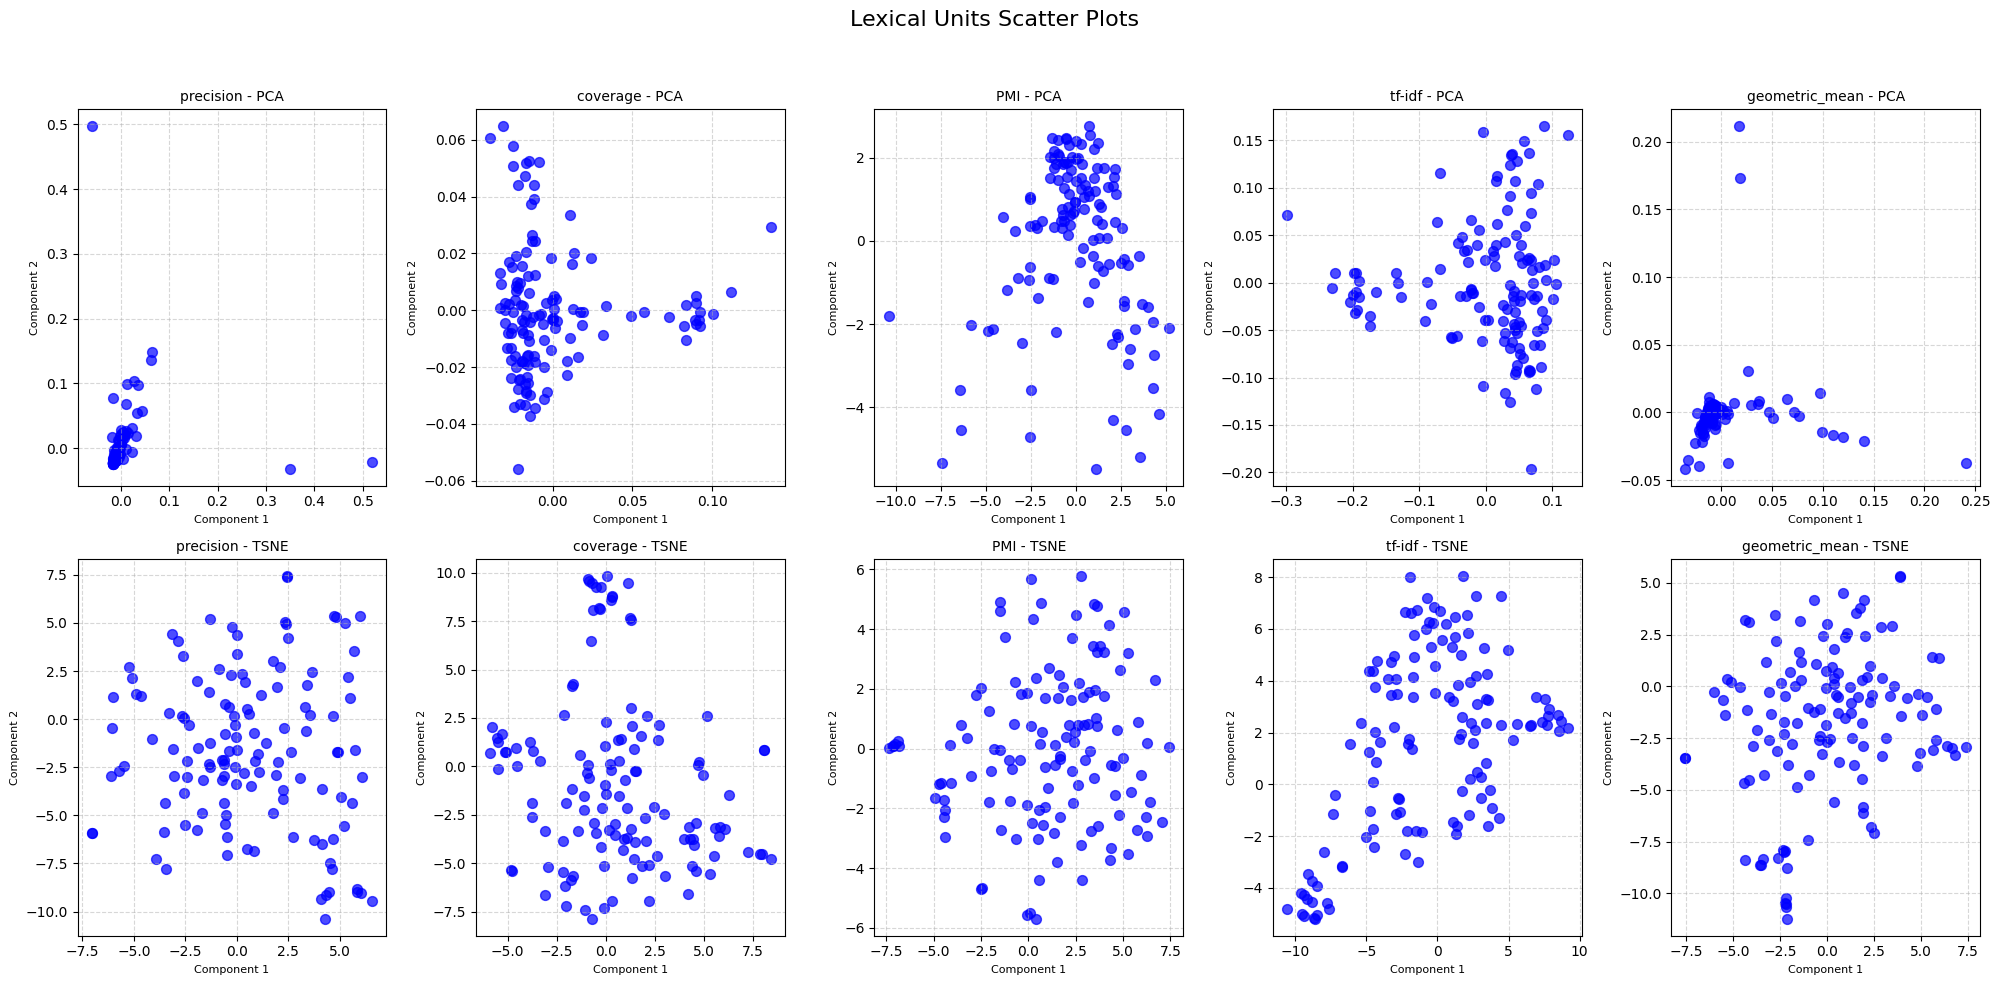

In [13]:
import matplotlib.pyplot as plt

def lexunit_scatter_plot(corpus, dimension_reduction, title, ax):
    """
    Create a scatter plot for lexical units using Matplotlib.
    """
    data = pd.DataFrame(
        {
            "Component 1": dimension_reduction.reduced_matrix[:, 0],
            "Component 2": dimension_reduction.reduced_matrix[:, 1],
            "Lexical Unit": [
                corpus.idx2lexunit(i)
                for i in range(len(dimension_reduction.reduced_matrix))
            ],
        }
    )

    # Create the scatter plot
    scatter = ax.scatter(data["Component 1"], data["Component 2"], s=50, alpha=0.7, c='blue')

    # Add text annotations for lexical units
    # for i, row in data.iterrows():
    #     ax.text(row["Component 1"], row["Component 2"], row["Lexical Unit"], fontsize=6, alpha=0.7)

    # Add plot titles and labels
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Component 1", fontsize=8)
    ax.set_ylabel("Component 2", fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

# Create a figure with subplots
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))  # 2 rows (PCA, t-SNE), 5 columns (matrix types)
fig.suptitle("Lexical Units Scatter Plots", fontsize=16)

# Iterate over the matrix types and dimension reduction methods
for col, type_of_matrix in enumerate(dim_reds.keys()):
    for row, dim_red in enumerate(['pca', 'tsne']):
        ax = axes[row, col]  # Get the subplot for the current row and column
        title = f"{type_of_matrix} - {dim_red.upper()}"  # Dynamic title
        lexunit_scatter_plot(corpus, dim_reds[type_of_matrix][dim_red], title, ax)

# Adjust layout for better spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the main title
plt.show()

In [14]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

def lexunit_scatter_plot_plotly(corpus, dim_reds):
    # Create a subplot layout with 2 rows (PCA, t-SNE) and 5 columns (matrix types)
    fig = make_subplots(
        rows=2, cols=5,
        subplot_titles=[f"{matrix_type} - PCA" for matrix_type in dim_reds.keys()] +
                       [f"{matrix_type} - t-SNE" for matrix_type in dim_reds.keys()],
        horizontal_spacing=0.05, vertical_spacing=0.15
    )

    # Iterate over the matrix types and dimension reduction methods
    for col, type_of_matrix in enumerate(dim_reds.keys(), start=1):
        for row, dim_red in enumerate(['pca', 'tsne'], start=1):
            # Get the dimension reduction object
            dimension_reduction = dim_reds[type_of_matrix][dim_red]

            # Prepare the data
            data = pd.DataFrame(
                {
                    "Component 1": dimension_reduction.reduced_matrix[:, 0],
                    "Component 2": dimension_reduction.reduced_matrix[:, 1],
                    "Lexical Unit": [
                        corpus.idx2lexunit(i)
                        for i in range(len(dimension_reduction.reduced_matrix))
                    ],
                }
            )

            # Add scatter plot to the subplot
            fig.add_trace(
                go.Scatter(
                    x=data["Component 1"],
                    y=data["Component 2"],
                    mode="markers",
                    marker=dict(size=8),
                    text=data["Lexical Unit"],  # Hover text
                    hovertemplate="Lexical Unit: %{text}<br>Component 1: %{x:.2f}<br>Component 2: %{y:.2f}<extra></extra>",
                ),
                row=row, col=col
            )

    # Update layout
    fig.update_layout(
        height=800,  # Adjust height
        width=1200,  # Adjust width
        title_text="Lexical Units Scatter Plots",
        showlegend=False,  # Hide legend
    )

    # Show the plot
    fig.show()

In [15]:
lexunit_scatter_plot_plotly(corpus, dim_reds)

In [16]:
for type_of_matrix, _ in dim_reds.items():
    print(f"{type_of_matrix}: {dim_reds[type_of_matrix]['pca'].explained_variance}")

precision: [0.21480333 0.18706876]
coverage: [0.31736715 0.11707336]
PMI: [0.14359207 0.09059937]
tf-idf: [0.33753858 0.18754181]
geometric_mean: [0.22574786 0.11866557]


In [ ]:
# corpora = {}
# for type_of_matrix in types_of_matrix:
#     corpus = tod.corpus.Corpus(
#     treebank_path=treebank_path,
#     grew_pattern=grew_pattern,
#     patterns_text_file=patterns_text_file,
#     matrix_type=type_of_matrix
# )
#     corpora[type_of_matrix] = corpus

In [ ]:
# corpora

In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
import pandas as pd

def lexunit_scatter_plot_with_kmeans(matrices, dim_reds, n_clusters=3):
    """
    Create a Plotly figure with subplots for PCA and t-SNE projections,
    with K-Means clustering applied to each corpus.
    """
    # Create a subplot layout with 2 rows (PCA, t-SNE) and 5 columns (matrix types)
    fig = make_subplots(
        rows=2, cols=5,
        subplot_titles=[f"{matrix_type} - PCA" for matrix_type in dim_reds.keys()] +
                       [f"{matrix_type} - t-SNE" for matrix_type in dim_reds.keys()],
        horizontal_spacing=0.05, vertical_spacing=0.15
    )

    # Iterate over the matrix types and dimension reduction methods
    for col, type_of_matrix in enumerate(dim_reds.keys(), start=1):
        # Get the corpus and feature matrix for the current matrix type
        X = matrices[type_of_matrix]
   

        # Apply K-Means clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels = kmeans.fit_predict(X)

        for row, dim_red in enumerate(['pca', 'tsne'], start=1):
            # Get the dimension reduction object
            dimension_reduction = dim_reds[type_of_matrix][dim_red]

            # Prepare the data
            data = pd.DataFrame(
                {
                    "Component 1": dimension_reduction.reduced_matrix[:, 0],
                    "Component 2": dimension_reduction.reduced_matrix[:, 1],
                    "Cluster": labels,  # Add cluster labels
                    "Lexical Unit": [
                        corpus.idx2lexunit(i)
                        for i in range(len(dimension_reduction.reduced_matrix))
                    ],
                }
            )

            # Add scatter plot to the subplot
            fig.add_trace(
                go.Scatter(
                    x=data["Component 1"],
                    y=data["Component 2"],
                    mode="markers",
                    marker=dict(size=8, color=data["Cluster"], colorscale="Viridis"),
                    text=data["Lexical Unit"],  # Hover text
                    hovertemplate="Lexical Unit: %{text}<br>Component 1: %{x:.2f}<br>Component 2: %{y:.2f}<br>Cluster: %{marker.color}<extra></extra>",
                ),
                row=row, col=col
            )

    # Update layout
    fig.update_layout(
        height=800,  # Adjust height
        width=1200,  # Adjust width
        title_text="Lexical Units Scatter Plots with K-Means Clustering",
        showlegend=False,  # Hide legend
    )

    # Show the plot
    fig.show()

lexunit_scatter_plot_with_kmeans(matrices, dim_reds, n_clusters=2)